Total Missing Values:
CA125_U_per_mL             0
Overall_Survival_Months    0
dtype: int64
=== DETEKSI OUTLIER ===

Variabel: CA125_U_per_mL
  - Outlier (IQR): 5
  - Outlier (Z-score > 3): 1
  - Batas: -16024.12 s/d 47322.88
  - Contoh nilai outlier: [51809 57206 51534 47908 88465]
------------------------------
Variabel: Overall_Survival_Months
  - Outlier (IQR): 16
  - Outlier (Z-score > 3): 0
  - Batas: 2302.88 s/d 7343.88
  - Contoh nilai outlier: [468 513 553 516 532]
------------------------------
=== CEK INCONSISTENCY ===
CA125 negatif: 0
Survival negatif: 0
Duplikasi data: 0


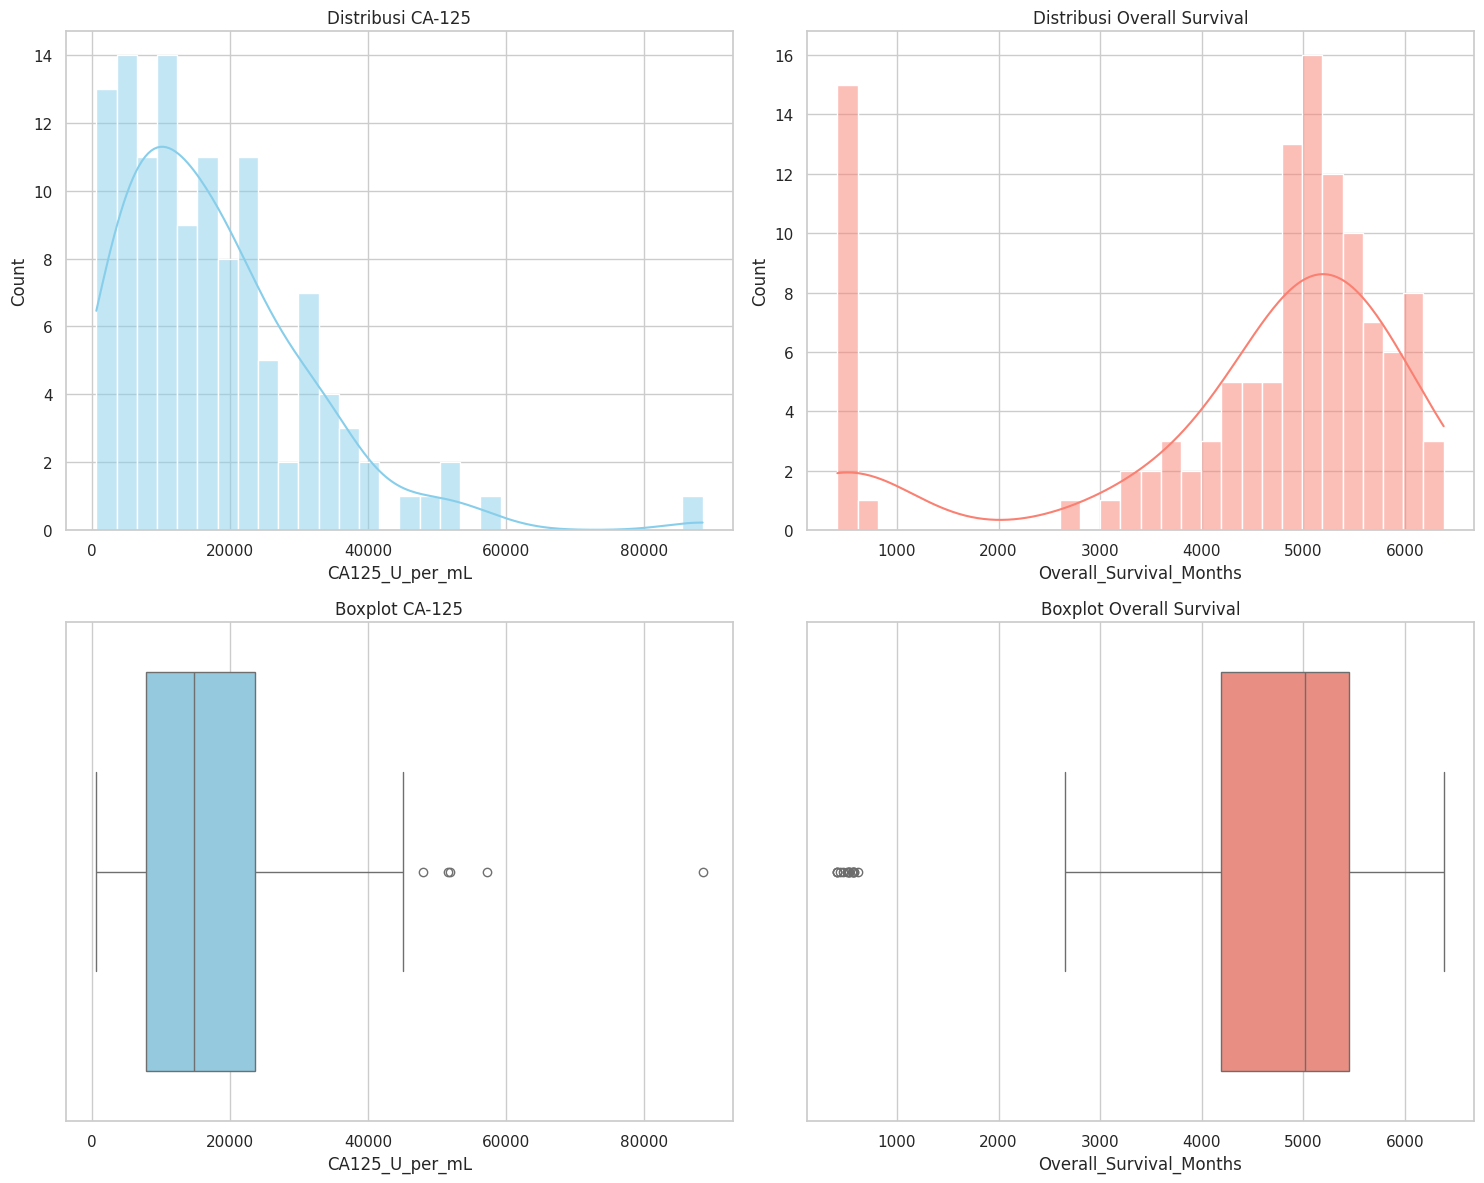

=== HASIL ANALISIS KORELASI ===
Koefisien Korelasi (r): -0.258
P-Value: 0.0044
Interpretasi: Hubungan Negatif dengan kekuatan Lemah

Keputusan: Tolak H0 (Signifikan secara statistik)


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setting visualisasi agar lebih rapi
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load data
df = pd.read_csv('ovarian_cancer_CA125_dataset.csv', sep=';')
data = df[['CA125_U_per_mL', 'Overall_Survival_Months']]

# Cek Missing Values
print(f"Total Missing Values:\n{data.isnull().sum()}")

def detect_outliers(df_input):
    print("=== DETEKSI OUTLIER ===\n")

    numeric_cols = df_input.select_dtypes(include=[np.number]).columns

    for var in numeric_cols:
        col_data = df_input[var].dropna()

        # Metode IQR
        q1 = col_data.quantile(0.25)
        q3 = col_data.quantile(0.75)
        iqr_val = q3 - q1
        lower_bound = q1 - 1.5 * iqr_val
        upper_bound = q3 + 1.5 * iqr_val

        outliers_iqr = col_data[(col_data < lower_bound) | (col_data > upper_bound)]

        # Metode Z-Score
        z_scores = np.abs(stats.zscore(col_data))
        outliers_z = col_data[z_scores > 3]

        print(f"Variabel: {var}")
        print(f"  - Outlier (IQR): {len(outliers_iqr)}")
        print(f"  - Outlier (Z-score > 3): {len(outliers_z)}")
        print(f"  - Batas: {lower_bound:.2f} s/d {upper_bound:.2f}")
        if len(outliers_iqr) > 0:
            print(f"  - Contoh nilai outlier: {outliers_iqr.unique()[:5]}")
        print("-" * 30)

detect_outliers(data)

print("=== CEK INCONSISTENCY ===")
print(f"CA125 negatif: {(df['CA125_U_per_mL'] < 0).sum()}")
print(f"Survival negatif: {(df['Overall_Survival_Months'] < 0).sum()}")
print(f"Duplikasi data: {df.duplicated().sum()}")

# Drop baris yang memiliki nilai kosong untuk analisis korelasi
df_clean = df.dropna(subset=['CA125_U_per_mL', 'Overall_Survival_Months'])

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# CA125 Distribution
sns.histplot(df_clean['CA125_U_per_mL'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribusi CA-125')

# Survival Distribution
sns.histplot(df_clean['Overall_Survival_Months'], bins=30, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Distribusi Overall Survival')

# Boxplots
sns.boxplot(x=df_clean['CA125_U_per_mL'], ax=axes[1,0], color='skyblue')
axes[1,0].set_title('Boxplot CA-125')

sns.boxplot(x=df_clean['Overall_Survival_Months'], ax=axes[1,1], color='salmon')
axes[1,1].set_title('Boxplot Overall Survival')

plt.tight_layout()
plt.show()

# Hitung Pearson
r, p_value = stats.pearsonr(df_clean['CA125_U_per_mL'], df_clean['Overall_Survival_Months'])

# Logika Interpretasi
if abs(r) > 0.8: interpretasi = "Sangat Kuat"
elif abs(r) > 0.6: interpretasi = "Kuat"
elif abs(r) > 0.4: interpretasi = "Sedang"
elif abs(r) > 0.2: interpretasi = "Lemah"
else: interpretasi = "Sangat Lemah"

arah = "Positif" if r > 0 else "Negatif"

print(f"=== HASIL ANALISIS KORELASI ===")
print(f"Koefisien Korelasi (r): {r:.3f}")
print(f"P-Value: {p_value:.4f}")
print(f"Interpretasi: Hubungan {arah} dengan kekuatan {interpretasi}")

# Uji Signifikansi
alpha = 0.05
if p_value < alpha:
    print("\nKeputusan: Tolak H0 (Signifikan secara statistik)")
else:
    print("\nKeputusan: Gagal Tolak H0 (Tidak signifikan)")